In [1]:
from __future__ import annotations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / 'tcav-v2-quality-tcav_rows.csv').exists():
    REPO_ROOT = REPO_ROOT.parent

rows_df = pd.read_csv(REPO_ROOT / 'tcav-v2-quality-tcav_rows.csv')

SEED = 1337
ENROLL_RATIO = 0.50  # ← change this to try other splits
EXAMPLES = ['id00012', 'id00016', 'id00018']

speakers = sorted(rows_df['true label'].unique().tolist())
concepts = sorted(rows_df['concept name'].unique().tolist())

print(f'Speakers:              {len(speakers)}')
print(f'Concepts:              {len(concepts)}')
recs = rows_df.groupby('true label')['path'].nunique().iloc[0]
print(f'Recordings / speaker:  {recs}')
print(f'ENROLL_RATIO:          {ENROLL_RATIO}')

Speakers:              10
Concepts:              28
Recordings / speaker:  20
ENROLL_RATIO:          0.5


## Step 1 — Enrollment / Test Split

In [2]:
enroll_parts, test_parts = [], []
test_recordings = {}  # speaker → list of test paths

for spk in speakers:
    spk_df = rows_df[rows_df['true label'] == spk]
    paths = sorted(spk_df['path'].dropna().astype(str).unique().tolist())
    shuffled = pd.Series(paths).sample(frac=1.0, random_state=SEED).tolist()

    n_enroll = int(round(len(shuffled) * ENROLL_RATIO))
    e_paths = set(shuffled[:n_enroll])
    t_paths = set(shuffled[n_enroll:])
    assert len(t_paths) >= 1

    enroll_parts.append(spk_df[spk_df['path'].isin(e_paths)])
    test_parts.append(spk_df[spk_df['path'].isin(t_paths)])
    test_recordings[spk] = sorted(t_paths)

enroll_df = pd.concat(enroll_parts, ignore_index=True)
test_df = pd.concat(test_parts, ignore_index=True)

n_e = enroll_df.groupby('true label')['path'].nunique().iloc[0]
n_t = test_df.groupby('true label')['path'].nunique().iloc[0]
print(f'Per speaker:  {n_e} enrollment  |  {n_t} test')
print(f'Total rows:   {len(enroll_df):,} enrollment  |  {len(test_df):,} test')
print()
for spk in EXAMPLES:
    fnames = [p.rsplit('/', 1)[-1] for p in test_recordings[spk]]
    print(f'  {spk}:  test files = {fnames}')

Per speaker:  10 enrollment  |  10 test
Total rows:   22,400 enrollment  |  22,400 test

  id00012:  test files = ['00007.m4a', '00008.m4a', '00009.m4a', '00010.m4a', '00011.m4a', '00015.m4a', '00017.m4a', '00018.m4a', '00019.m4a', '00020.m4a']
  id00016:  test files = ['00007.m4a', '00008.m4a', '00009.m4a', '00010.m4a', '00011.m4a', '00015.m4a', '00017.m4a', '00018.m4a', '00019.m4a', '00020.m4a']
  id00018:  test files = ['00007.m4a', '00008.m4a', '00009.m4a', '00010.m4a', '00011.m4a', '00015.m4a', '00017.m4a', '00018.m4a', '00019.m4a', '00020.m4a']


## Step 2 — Enrollment Vectors & Centroids

Build one 28-D concept vector per speaker, then K-Means to get centroids.

In [3]:
enrollment_matrix = (
    enroll_df
    .groupby(['true label', 'concept name'])['pos_effect_delta']
    .mean()
    .unstack(fill_value=0.0)
    .reindex(columns=concepts, fill_value=0.0)
    .sort_index()
)

# K-Means (k = n_speakers → one centroid per speaker)
n_clusters = len(speakers)
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init='auto')
cluster_labels = kmeans.fit_predict(enrollment_matrix.values)
centroids = pd.DataFrame(kmeans.cluster_centers_, columns=concepts)
centroids.index.name = 'cluster_id'

cluster_to_speaker = {}
speaker_to_cluster = {}
for spk, lbl in zip(enrollment_matrix.index, cluster_labels):
    cluster_to_speaker[int(lbl)] = str(spk)
    speaker_to_cluster[str(spk)] = int(lbl)

print(f'Enrollment matrix: {enrollment_matrix.shape[0]} speakers \u00d7 '
      f'{enrollment_matrix.shape[1]} concepts')
print(f'Clusters: {n_clusters}  (1 speaker each)')
print()
for cid in sorted(cluster_to_speaker):
    print(f'  cluster {cid} \u2192 {cluster_to_speaker[cid]}')

Enrollment matrix: 10 speakers × 28 concepts
Clusters: 10  (1 speaker each)

  cluster 0 → id00018
  cluster 1 → id00022
  cluster 2 → id00019
  cluster 3 → id00016
  cluster 4 → id00025
  cluster 5 → id00021
  cluster 6 → id00012
  cluster 7 → id00020
  cluster 8 → id00026
  cluster 9 → id00024


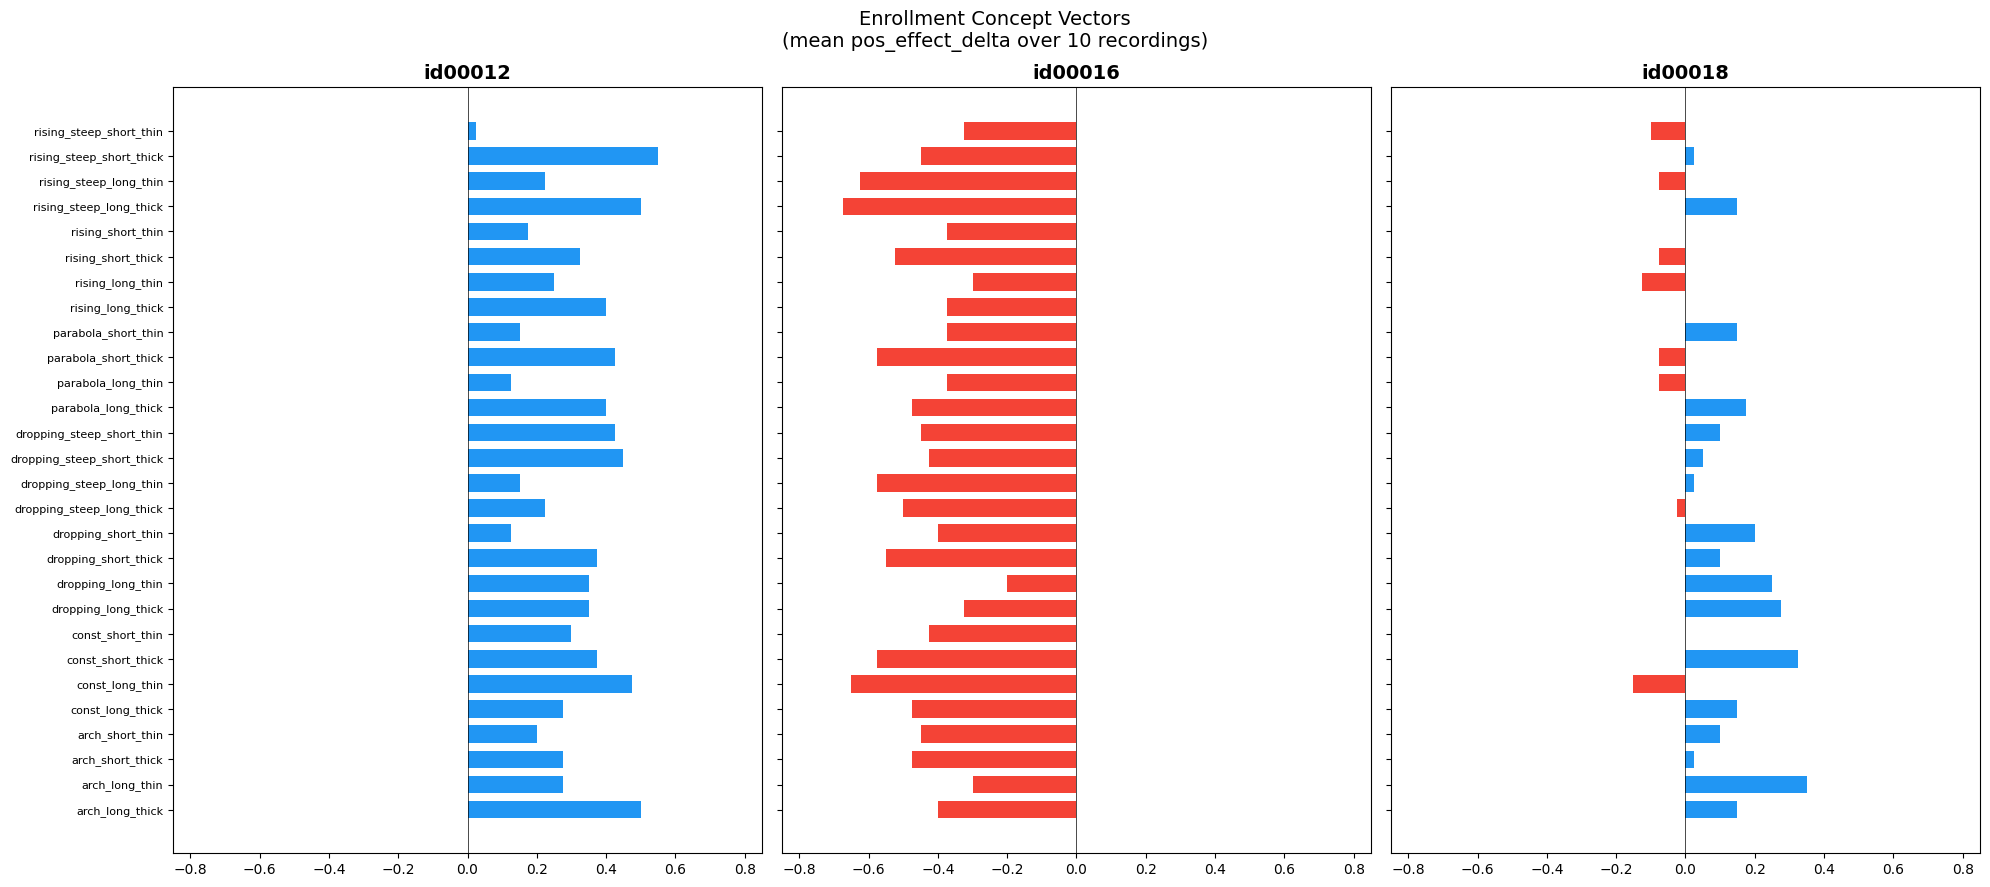

In [4]:
# Enrollment vector bar charts for 3 example speakers
fig, axes = plt.subplots(1, 3, figsize=(20, 9), sharey=True)
for i, (ax, spk) in enumerate(zip(axes, EXAMPLES)):
    vec = enrollment_matrix.loc[spk]
    colors = ['#2196F3' if v >= 0 else '#f44336' for v in vec]
    ax.barh(concepts, vec.values, color=colors, height=0.7)
    ax.set_title(spk, fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    ax.set_xlim(-0.85, 0.85)
    ax.tick_params(axis='y', labelsize=8)
fig.suptitle(
    f'Enrollment Concept Vectors\n(mean pos_effect_delta over {n_e} recordings)',
    fontsize=14,
)
plt.tight_layout()
plt.show()

## Step 3 — Score Each Test Recording Against All Centroids

For each test recording we:
1. Compute its concept vector (mean `pos_effect_delta` per concept).
2. Convert to a **sign vector** (+1 / −1).
3. Score against every centroid: `score = Σ centroid_i × sign_i`.

In [5]:
# Build per-recording scores
per_rec_rows = []

for spk in speakers:
    for tpath in test_recordings[spk]:
        mask = (test_df['true label'] == spk) & (test_df['path'] == tpath)
        raw_vec = (
            test_df[mask]
            .groupby('concept name')['pos_effect_delta']
            .mean()
            .reindex(concepts, fill_value=0.0)
        )
        sign_vec = raw_vec.apply(lambda x: 1.0 if x > 0 else -1.0)

        for cid, centroid_row in centroids.iterrows():
            score = float((centroid_row * sign_vec).sum())
            per_rec_rows.append({
                'true_speaker': spk,
                'test_path': tpath,
                'cluster_id': int(cid),
                'centroid_speaker': cluster_to_speaker[int(cid)],
                'score': score,
            })

per_rec_df = pd.DataFrame(per_rec_rows)
print(f'Per-recording scores: {len(per_rec_df):,} rows  '
      f'({len(speakers)} speakers \u00d7 {n_t} test recs \u00d7 {n_clusters} centroids)')

# Show individual scores for the first example speaker
spk = EXAMPLES[0]
spk_recs = per_rec_df[per_rec_df['true_speaker'] == spk]
for tpath in test_recordings[spk]:
    fname = tpath.rsplit('/', 1)[-1]
    rec_scores = spk_recs[spk_recs['test_path'] == tpath].sort_values('score', ascending=False)
    print(f'\n  {spk} / {fname}:')
    for _, r in rec_scores.iterrows():
        flag = ' \u2190 TRUE' if r['centroid_speaker'] == spk else ''
        print(f'    vs {r["centroid_speaker"]}  {r["score"]:+8.3f}{flag}')

Per-recording scores: 1,000 rows  (10 speakers × 10 test recs × 10 centroids)

  id00012 / 00007.m4a:
    vs id00022    +3.900
    vs id00026    +1.700
    vs id00016    +1.625
    vs id00018    +0.900
    vs id00012    +0.725 ← TRUE
    vs id00020    +0.225
    vs id00021    -1.000
    vs id00019    -1.550
    vs id00024    -1.775
    vs id00025    -3.150

  id00012 / 00008.m4a:
    vs id00025   +10.150
    vs id00024    +9.425
    vs id00019    +6.500
    vs id00012    +5.925 ← TRUE
    vs id00021    +4.900
    vs id00018    +0.550
    vs id00020    -0.125
    vs id00026    -5.700
    vs id00016    -8.025
    vs id00022   -15.200

  id00012 / 00009.m4a:
    vs id00025   +17.950
    vs id00024   +14.975
    vs id00019   +11.400
    vs id00021   +11.250
    vs id00012    +8.675 ← TRUE
    vs id00018    +1.900
    vs id00020    +0.175
    vs id00026    -9.250
    vs id00016   -12.625
    vs id00022   -27.150

  id00012 / 00010.m4a:
    vs id00025   +17.950
    vs id00024   +14.975
    v

## Step 4 — Average Scores Across Test Recordings


In [6]:
# Average score per (true_speaker, cluster_id) across all test recordings
mean_scores = (
    per_rec_df
    .groupby(['true_speaker', 'cluster_id', 'centroid_speaker'])['score']
    .mean()
    .reset_index()
    .rename(columns={'score': 'mean_score'})
)

# Best centroid per speaker
best = (
    mean_scores
    .sort_values('mean_score', ascending=False)
    .groupby('true_speaker')
    .first()
    .reset_index()
)
best['correct'] = best['true_speaker'] == best['centroid_speaker']

# Show for 3 example speakers
for spk in EXAMPLES:
    ranked = (
        mean_scores[mean_scores['true_speaker'] == spk]
        .sort_values('mean_score', ascending=False)
    )
    top_spk = ranked.iloc[0]['centroid_speaker']
    expected_cid = speaker_to_cluster[spk]
    expected_score = ranked[ranked['cluster_id'] == expected_cid]['mean_score'].iloc[0]
    print(f'\n{spk}  (expected cluster {expected_cid})')
    print(f'  Mean scores across {n_t} test recordings:')
    for _, r in ranked.iterrows():
        flags = ''
        if r['centroid_speaker'] == spk:
            flags += ' \u2190 TRUE'
        if r['centroid_speaker'] == top_spk:
            flags += ' \u2605 BEST'
        print(f'    vs {r["centroid_speaker"]} (C{int(r["cluster_id"])})  '
              f'{r["mean_score"]:+8.3f}{flags}')


id00012  (expected cluster 6)
  Mean scores across 10 test recordings:
    vs id00024 (C9)    +1.450 ★ BEST
    vs id00025 (C4)    +1.435
    vs id00012 (C6)    +1.205 ← TRUE
    vs id00019 (C2)    +0.990
    vs id00021 (C5)    +0.810
    vs id00018 (C0)    +0.175
    vs id00020 (C7)    -0.045
    vs id00026 (C8)    -0.805
    vs id00016 (C3)    -1.285
    vs id00022 (C1)    -2.285

id00016  (expected cluster 3)
  Mean scores across 10 test recordings:
    vs id00022 (C1)   +12.125 ★ BEST
    vs id00016 (C3)    +6.405 ← TRUE
    vs id00026 (C8)    +4.175
    vs id00020 (C7)    +0.250
    vs id00018 (C0)    -0.605
    vs id00021 (C5)    -4.130
    vs id00012 (C6)    -4.430
    vs id00019 (C2)    -5.395
    vs id00024 (C9)    -7.380
    vs id00025 (C4)    -8.095

id00018  (expected cluster 0)
  Mean scores across 10 test recordings:
    vs id00022 (C1)   +17.640 ★ BEST
    vs id00016 (C3)    +8.270
    vs id00026 (C8)    +6.025
    vs id00020 (C7)    -0.025
    vs id00018 (C0)    -0.810

## Step 5 — Accuracy & Distance to Centroids

How close is each speaker's averaged test profile to their own centroid
vs others?

In [7]:
# Accuracy
n_correct = int(best['correct'].sum())
n_total = len(best)
print(f'Identification accuracy (mean-score method): {n_correct}/{n_total} '
      f'({n_correct / n_total:.0%})')
print()

# Per-speaker table
for spk in speakers:
    row = best[best['true_speaker'] == spk].iloc[0]
    status = '\u2713' if row['correct'] else '\u2717'
    expected = speaker_to_cluster[spk]
    own_score = mean_scores[
        (mean_scores['true_speaker'] == spk) & (mean_scores['cluster_id'] == expected)
    ]['mean_score'].iloc[0]
    gap = own_score - row['mean_score'] if not row['correct'] else 0.0
    line = f'  {spk}  \u2192 predicted {row["centroid_speaker"]}  {status}'
    line += f'   own-centroid score: {own_score:+.2f}'
    if not row['correct']:
        line += f'   (gap to best: {gap:+.2f})'
    print(line)

Identification accuracy (mean-score method): 2/10 (20%)

  id00012  → predicted id00024  ✗   own-centroid score: +1.20   (gap to best: -0.25)
  id00016  → predicted id00022  ✗   own-centroid score: +6.40   (gap to best: -5.72)
  id00018  → predicted id00022  ✗   own-centroid score: -0.81   (gap to best: -18.45)
  id00019  → predicted id00025  ✗   own-centroid score: +1.07   (gap to best: -0.44)
  id00020  → predicted id00022  ✗   own-centroid score: -0.03   (gap to best: -15.93)
  id00021  → predicted id00022  ✗   own-centroid score: -0.53   (gap to best: -3.78)
  id00022  → predicted id00022  ✓   own-centroid score: +23.66
  id00024  → predicted id00025  ✗   own-centroid score: +9.86   (gap to best: -1.88)
  id00025  → predicted id00025  ✓   own-centroid score: +13.14
  id00026  → predicted id00022  ✗   own-centroid score: +2.06   (gap to best: -3.92)


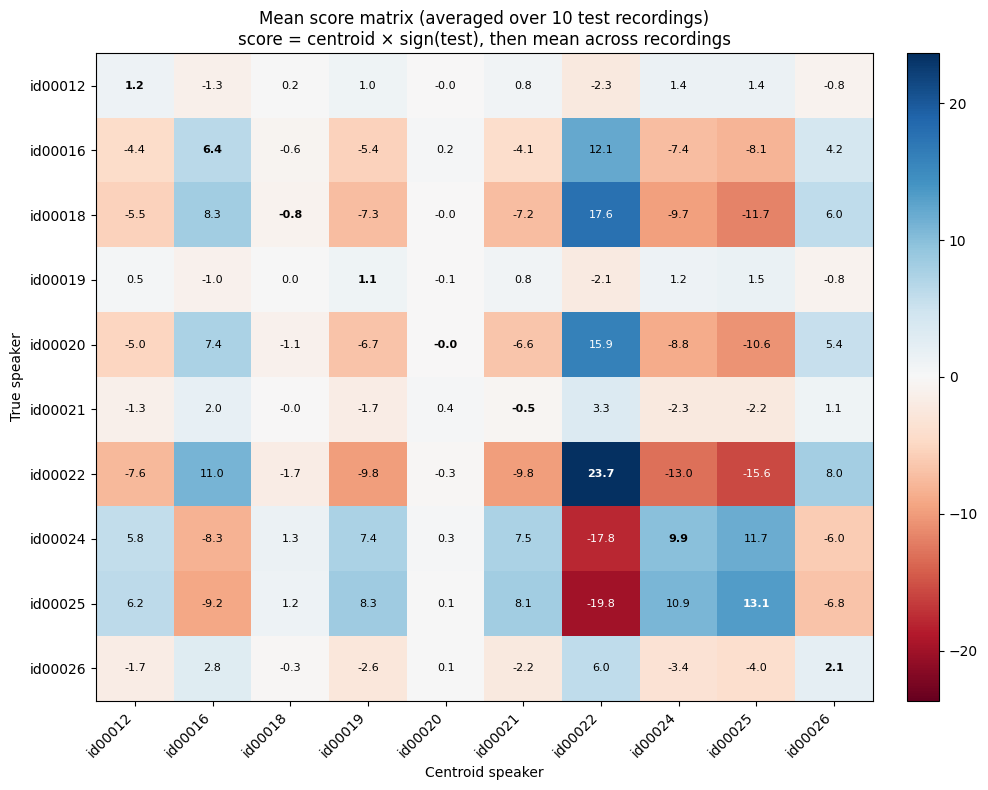

In [8]:
# Mean score matrix: true speaker (rows) vs centroid speaker (cols)
score_pivot = mean_scores.pivot(
    index='true_speaker', columns='centroid_speaker', values='mean_score',
).reindex(index=speakers, columns=speakers)

fig, ax = plt.subplots(figsize=(10, 8))
vmax = max(abs(score_pivot.values.min()), abs(score_pivot.values.max()))
im = ax.imshow(score_pivot.values, cmap='RdBu', vmin=-vmax, vmax=vmax, aspect='auto')
ax.set_xticks(range(len(speakers)))
ax.set_yticks(range(len(speakers)))
ax.set_xticklabels(speakers, rotation=45, ha='right')
ax.set_yticklabels(speakers)
ax.set_xlabel('Centroid speaker')
ax.set_ylabel('True speaker')
ax.set_title(
    f'Mean score matrix (averaged over {n_t} test recordings)\n'
    f'score = centroid \u00d7 sign(test), then mean across recordings'
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(speakers)):
    for j in range(len(speakers)):
        v = score_pivot.values[i, j]
        color = 'white' if abs(v) > vmax * 0.55 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, f'{v:.1f}', ha='center', va='center',
                color=color, fontsize=8, fontweight=weight)
plt.tight_layout()
plt.show()

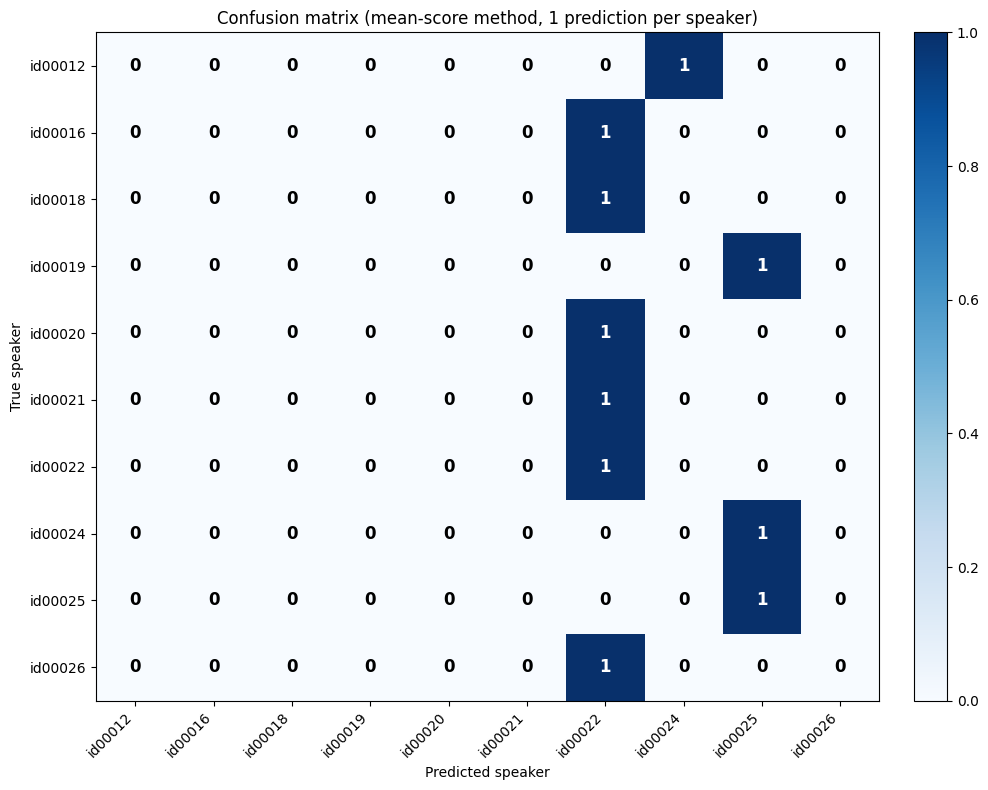

In [9]:
# Confusion matrix (mean-score prediction)
confusion = pd.crosstab(
    best['true_speaker'], best['centroid_speaker'],
).reindex(index=speakers, columns=speakers, fill_value=0)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(confusion.values, cmap='Blues', aspect='auto')
ax.set_xticks(range(len(speakers)))
ax.set_yticks(range(len(speakers)))
ax.set_xticklabels(speakers, rotation=45, ha='right')
ax.set_yticklabels(speakers)
ax.set_xlabel('Predicted speaker')
ax.set_ylabel('True speaker')
ax.set_title('Confusion matrix (mean-score method, 1 prediction per speaker)')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

threshold = confusion.to_numpy().max() / 2 if confusion.size else 0
for i in range(len(speakers)):
    for j in range(len(speakers)):
        v = int(confusion.values[i, j])
        color = 'white' if v > threshold else 'black'
        ax.text(j, i, str(v), ha='center', va='center',
                color=color, fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Cosine Distance to Centroids

**mean test concept vector** per speaker then measure
the **cosine similarity** between that averaged test vector and every centroid.

In [10]:
from numpy.linalg import norm

# Mean test concept vector per speaker (raw values, not signs)
mean_test_vecs = {}
for spk in speakers:
    vecs = []
    for tpath in test_recordings[spk]:
        mask = (test_df['true label'] == spk) & (test_df['path'] == tpath)
        v = test_df[mask].groupby('concept name')['pos_effect_delta'].mean()
        vecs.append(v.reindex(concepts, fill_value=0.0).values)
    mean_test_vecs[spk] = np.mean(vecs, axis=0)

# Cosine similarity: mean test vector vs each centroid
cos_rows = []
for spk in speakers:
    tv = mean_test_vecs[spk]
    for cid, crow in centroids.iterrows():
        cv = crow.values
        cos_sim = float(np.dot(tv, cv) / (norm(tv) * norm(cv) + 1e-12))
        cos_rows.append({
            'true_speaker': spk,
            'cluster_id': int(cid),
            'centroid_speaker': cluster_to_speaker[int(cid)],
            'cosine_similarity': cos_sim,
        })

cos_df = pd.DataFrame(cos_rows)

# Best by cosine
best_cos = (
    cos_df.sort_values('cosine_similarity', ascending=False)
    .groupby('true_speaker').first().reset_index()
)
best_cos['correct'] = best_cos['true_speaker'] == best_cos['centroid_speaker']

n_correct_cos = int(best_cos['correct'].sum())
print(f'Cosine-similarity accuracy: {n_correct_cos}/{n_total} '
      f'({n_correct_cos / n_total:.0%})')
print()
for spk in speakers:
    row = best_cos[best_cos['true_speaker'] == spk].iloc[0]
    own_cid = speaker_to_cluster[spk]
    own_cos = cos_df[
        (cos_df['true_speaker'] == spk) & (cos_df['cluster_id'] == own_cid)
    ]['cosine_similarity'].iloc[0]
    status = '\u2713' if row['correct'] else '\u2717'
    line = f'  {spk}  \u2192 predicted {row["centroid_speaker"]}  {status}'
    line += f'   own cosine: {own_cos:.4f}   best cosine: {row["cosine_similarity"]:.4f}'
    print(line)

Cosine-similarity accuracy: 5/10 (50%)

  id00012  → predicted id00012  ✓   own cosine: 0.9306   best cosine: 0.9306
  id00016  → predicted id00016  ✓   own cosine: 0.9168   best cosine: 0.9168
  id00018  → predicted id00016  ✗   own cosine: -0.1120   best cosine: 0.9039
  id00019  → predicted id00019  ✓   own cosine: 0.9316   best cosine: 0.9316
  id00020  → predicted id00022  ✗   own cosine: 0.0327   best cosine: 0.9905
  id00021  → predicted id00016  ✗   own cosine: -0.4306   best cosine: 0.7487
  id00022  → predicted id00022  ✓   own cosine: 0.9969   best cosine: 0.9969
  id00024  → predicted id00025  ✗   own cosine: 0.9838   best cosine: 0.9842
  id00025  → predicted id00025  ✓   own cosine: 0.9947   best cosine: 0.9947
  id00026  → predicted id00022  ✗   own cosine: 0.8594   best cosine: 0.8743


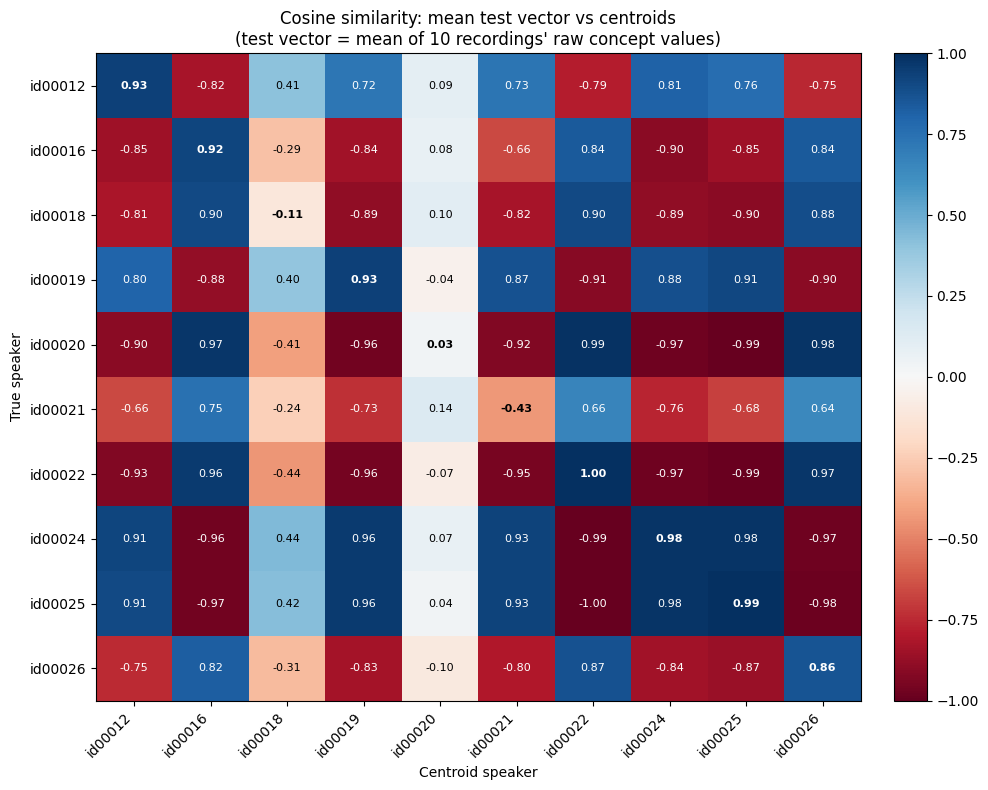

In [11]:
cos_pivot = cos_df.pivot(
    index='true_speaker', columns='centroid_speaker', values='cosine_similarity',
).reindex(index=speakers, columns=speakers)

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(cos_pivot.values, cmap='RdBu', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(speakers)))
ax.set_yticks(range(len(speakers)))
ax.set_xticklabels(speakers, rotation=45, ha='right')
ax.set_yticklabels(speakers)
ax.set_xlabel('Centroid speaker')
ax.set_ylabel('True speaker')
ax.set_title(
    f'Cosine similarity: mean test vector vs centroids\n'
    f'(test vector = mean of {n_t} recordings\' raw concept values)'
)
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

for i in range(len(speakers)):
    for j in range(len(speakers)):
        v = cos_pivot.values[i, j]
        color = 'white' if abs(v) > 0.55 else 'black'
        weight = 'bold' if i == j else 'normal'
        ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                color=color, fontsize=8, fontweight=weight)
plt.tight_layout()
plt.show()

## PCA Visualization


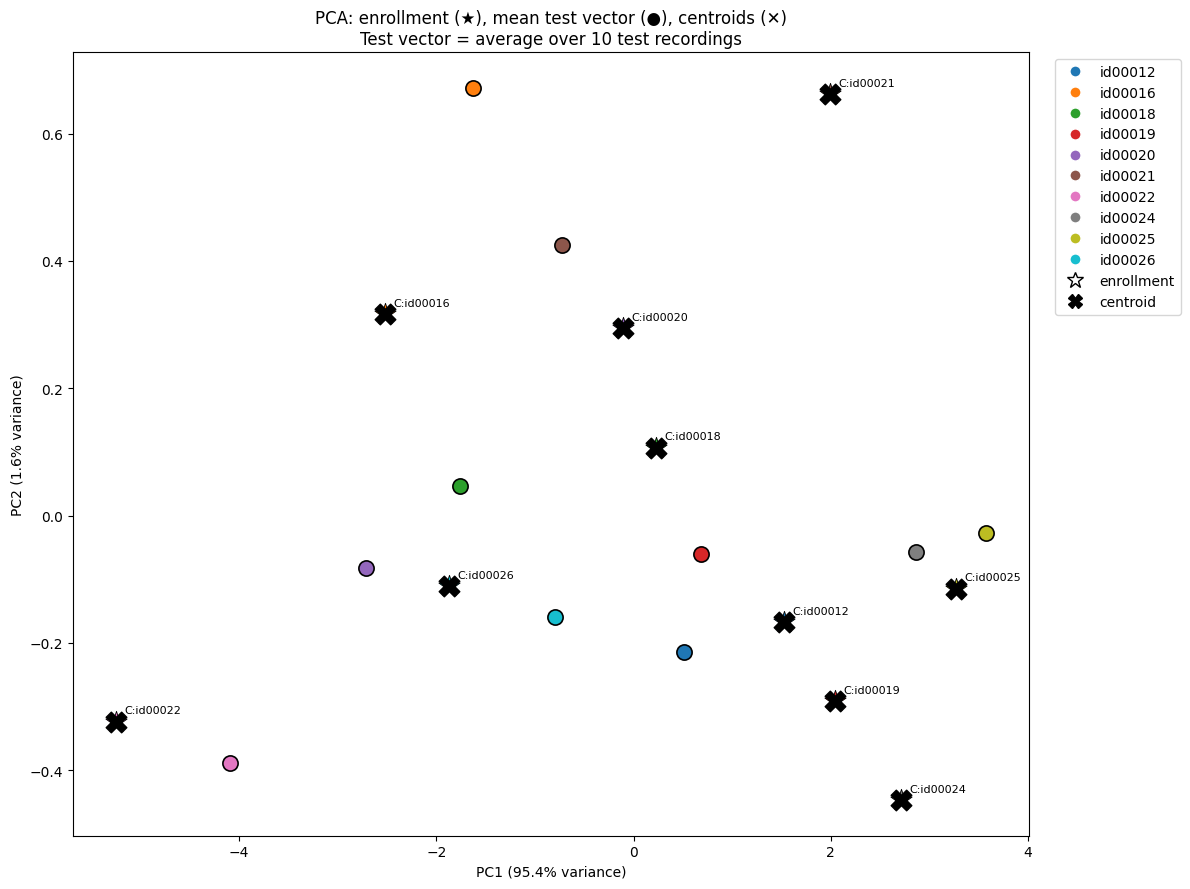

In [12]:
# PCA data
enroll_pca = enrollment_matrix.copy()
enroll_pca['point_type'] = 'enrollment'
enroll_pca['speaker'] = enroll_pca.index.astype(str)
enroll_pca = enroll_pca.reset_index(drop=True)

test_pca = pd.DataFrame(mean_test_vecs, index=concepts).T
test_pca = test_pca.reindex(columns=concepts)
test_pca['point_type'] = 'mean_test'
test_pca['speaker'] = test_pca.index.astype(str)
test_pca = test_pca.reset_index(drop=True)

cent_pca = centroids.copy()
cent_pca['point_type'] = 'centroid'
cent_pca['speaker'] = [cluster_to_speaker[i] for i in range(n_clusters)]

all_pts = pd.concat([enroll_pca, test_pca, cent_pca], ignore_index=True)

pca_model = PCA(n_components=2, random_state=SEED)
xy = pca_model.fit_transform(all_pts[concepts].values)
all_pts['pc1'] = xy[:, 0]
all_pts['pc2'] = xy[:, 1]

cmap = {spk: plt.cm.tab10(i % 10) for i, spk in enumerate(speakers)}
fig, ax = plt.subplots(figsize=(12, 9))

for spk in speakers:
    ev = all_pts[(all_pts['point_type'] == 'enrollment') & (all_pts['speaker'] == spk)]
    tv = all_pts[(all_pts['point_type'] == 'mean_test') & (all_pts['speaker'] == spk)]
    ax.scatter(ev['pc1'], ev['pc2'], marker='*', s=260, color=cmap[spk],
               edgecolors='black', linewidths=0.6, zorder=3)
    ax.scatter(tv['pc1'], tv['pc2'], marker='o', s=120, color=cmap[spk],
               edgecolors='black', linewidths=1.2, zorder=4, label=spk)

cv = all_pts[all_pts['point_type'] == 'centroid']
ax.scatter(cv['pc1'], cv['pc2'], marker='X', s=220, color='black', zorder=5)
for _, row in cv.iterrows():
    ax.annotate(f'C:{row["speaker"]}', (row['pc1'], row['pc2']),
                textcoords='offset points', xytext=(6, 6), fontsize=8)

handles = [
    Line2D([0], [0], marker='o', color='w', label=s,
           markerfacecolor=cmap[s], markersize=8)
    for s in speakers
] + [
    Line2D([0], [0], marker='*', color='k', label='enrollment',
           markerfacecolor='w', markersize=12, linewidth=0),
    Line2D([0], [0], marker='X', color='k', label='centroid',
           markerfacecolor='k', markersize=10, linewidth=0),
]
ax.legend(handles=handles, bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_title(
    f'PCA: enrollment (\u2605), mean test vector (\u25cf), centroids (\u2715)\n'
    f'Test vector = average over {n_t} test recordings'
)
ax.set_xlabel(f'PC1 ({pca_model.explained_variance_ratio_[0]:.1%} variance)')
ax.set_ylabel(f'PC2 ({pca_model.explained_variance_ratio_[1]:.1%} variance)')
plt.tight_layout()
plt.show()

In [13]:
print('\u2550' * 50)
print('  SUMMARY')
print('\u2550' * 50)
print(f'  ENROLL_RATIO:          {ENROLL_RATIO}')
print(f'  Enrollment / test:     {n_e} / {n_t} recordings per speaker')
print(f'  Speakers:              {len(speakers)}')
print(f'  Concepts:              {len(concepts)}')
print()
print(f'  Sign-score method:')
print(f'    accuracy (mean):     {n_correct}/{n_total} ({n_correct / n_total:.0%})')
print(f'    mean best score:     {best["mean_score"].mean():.2f}')
print()
print(f'  Cosine method:')
print(f'    accuracy:            {n_correct_cos}/{n_total} ({n_correct_cos / n_total:.0%})')
print(f'    mean best cosine:    {best_cos["cosine_similarity"].mean():.4f}')

══════════════════════════════════════════════════
  SUMMARY
══════════════════════════════════════════════════
  ENROLL_RATIO:          0.5
  Enrollment / test:     10 / 10 recordings per speaker
  Speakers:              10
  Concepts:              28

  Sign-score method:
    accuracy (mean):     2/10 (20%)
    mean best score:     10.64

  Cosine method:
    accuracy:            5/10 (50%)
    mean best cosine:    0.9272
